# Molecular Weight Distribution
Histogram of molecule sizes from `mixed_augment_labels.tsv`, with a stacked version split by carbon atom count.

In [26]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [27]:
ATOMIC_WEIGHTS = {
    'C': 12.011, 'H': 1.008, 'N': 14.007, 'O': 15.999,
    'S': 32.06,  'P': 30.974, 'F': 18.998, 'Cl': 35.45,
    'Br': 79.904, 'I': 126.904, 'Si': 28.086, 'Na': 22.990,
    'K': 39.098, 'Ca': 40.078, 'Fe': 55.845, 'Mg': 24.305,
    'B': 10.811, 'Se': 78.971, 'As': 74.922,
}

def parse_formula(formula, element='C'):
    """Return (monoisotopic-avg MW, carbon count) from a molecular formula string."""
    # Strip charge suffixes like +, -, 2+, 3-, etc.
    formula = re.sub(r'[+\-]\d*$', '', str(formula).strip())
    atoms = {}
    for elem, count in re.findall(r'([A-Z][a-z]?)(\d*)', formula):
        if elem in ATOMIC_WEIGHTS:
            atoms[elem] = atoms.get(elem, 0) + (int(count) if count else 1)
    mw = sum(ATOMIC_WEIGHTS[e] * n for e, n in atoms.items())
    return mw, atoms.get(element, 0)

In [28]:
df = pd.read_csv('data/mixed_augment_labels.tsv', sep='\t', index_col=0)
print(df.shape)
df.head(3)

(291065, 7)


,dataset,spec,ionization,formula,smiles,inchikey,instrument
0,mixed_augment_neims,mix_aug_0,[M]+,C8H11NO2,Cc1nc(O)c(C)c(O)c1C,DGFZETPZVVBGDX-UHFFFAOYSA-N,simulated
1,mixed_augment_neims,mix_aug_1,[M]+,C9H13NO2,CCCn1c(C)cc(O)cc1=O,PVPCCBVPEPJYMT-UHFFFAOYSA-N,simulated
2,mixed_augment_neims,mix_aug_2,[M]+,C9H11NO3,COC(=O)c1ccc(C)n(C)c1=O,VZNOBKUONZMASH-UHFFFAOYSA-N,simulated


In [29]:
parsed = df['formula'].apply(lambda x: parse_formula(x, 'C'))
df['mw']    = parsed.apply(lambda x: x[0])
df['n_carbon'] = parsed.apply(lambda x: x[1])
parsed = df['formula'].apply(lambda x: parse_formula(x, 'O'))
df['n_oxygen'] = parsed.apply(lambda x: x[1])

print(f"MW range : {df['mw'].min():.1f} – {df['mw'].max():.1f} Da")
print(f"Carbon   : {df['n_carbon'].min()} – {df['n_carbon'].max()}")
print(f"Rows outside 100–1500 Da: {((df['mw'] < 100) | (df['mw'] > 1500)).sum()}")

MW range : 100.0 – 1494.2 Da
Carbon   : 1 – 40
Rows outside 100–1500 Da: 0


## Plot 1 – plain MW histogram

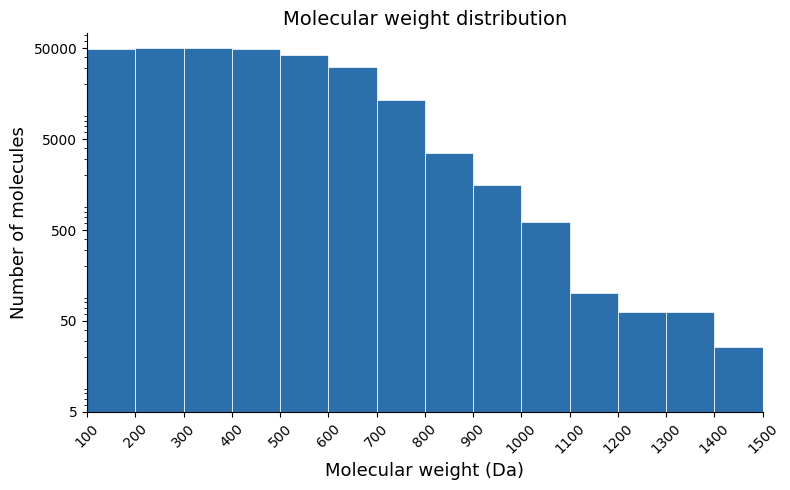

In [39]:
BINS = np.arange(100, 1601, 100)   # edges: 100, 200, …, 1600
IN_RANGE = (df['mw'] >= 100) & (df['mw'] <= 1500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df.loc[IN_RANGE, 'mw'], bins=BINS, color='#2c6fad', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Molecular weight (Da)', fontsize=13)
ax.set_ylabel('Number of molecules', fontsize=13)
ax.set_title('Molecular weight distribution', fontsize=14)
ax.set_xticks(BINS)
ax.set_xlim(100, 1500)
ax.set_yscale('log')
ax.xaxis.set_tick_params(rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_yticks([5, 50, 500, 5000, 50000], labels=[5, 50, 500, 5000, 50000])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mw_histogram.png', dpi=300)
plt.show()

## Plot 2 – stacked by carbon count

C:\Users\kuuli\AppData\Local\Temp\ipykernel_31652\3523471668.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')


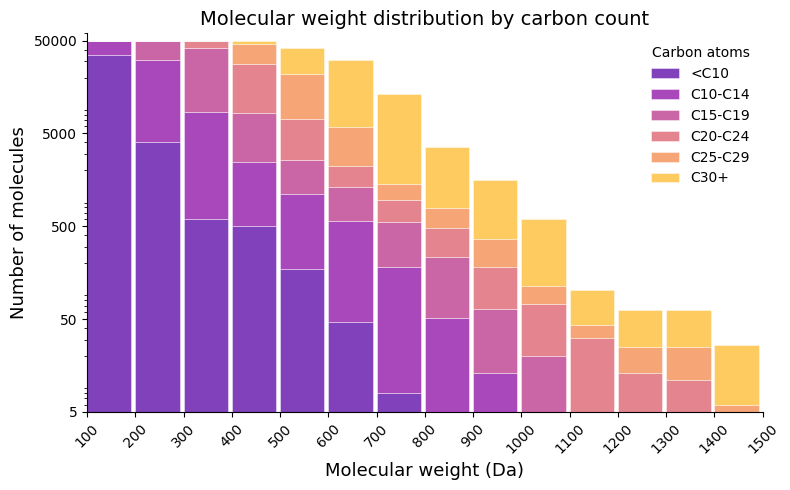

In [40]:
C_BINS   = [0, 10, 15, 20, 25, 30, np.inf]
C_LABELS = ['<C10', 'C10-C14', 'C15-C19', 'C20-C24', 'C25-C29', 'C30+']
cmap = plt.cm.get_cmap('plasma')
COLORS = [cmap(x) for x in np.linspace(0.15, 0.85, len(C_LABELS))]

df['c_group'] = pd.cut(df['n_carbon'], bins=C_BINS, labels=C_LABELS, right=False)

# Count molecules per (MW bin, C group)
mw_bins = pd.cut(df.loc[IN_RANGE, 'mw'], bins=BINS, right=False)
stacked = (
    df.loc[IN_RANGE]
    .assign(mw_bin=mw_bins)
    .groupby(['mw_bin', 'c_group'], observed=False)
    .size()
    .unstack('c_group', fill_value=0)
)

bin_width = 100
x_pos = np.array([interval.left for interval in stacked.index])

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(stacked))
for label, color in zip(C_LABELS, COLORS):
    if label not in stacked.columns:
        continue
    vals = stacked[label].values
    ax.bar(x_pos, vals, width=bin_width * 0.92, bottom=bottom,
           label=label, color=color, align='edge', edgecolor='white', linewidth=0.4,
           alpha=0.75)
    bottom += vals

ax.set_xlabel('Molecular weight (Da)', fontsize=13)
ax.set_ylabel('Number of molecules', fontsize=13)
ax.set_title('Molecular weight distribution by carbon count', fontsize=14)
ax.set_xticks(BINS)
ax.set_xlim(100, 1500)
ax.set_yscale('log')
ax.xaxis.set_tick_params(rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_yticks([5, 50, 500, 5000, 50000], labels=[5, 50, 500, 5000, 50000])
ax.legend(title='Carbon atoms', frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim([5, 60000])

plt.tight_layout()
plt.savefig('mw_histogram_stacked_carbon.png', dpi=300)
plt.show()

C:\Users\kuuli\AppData\Local\Temp\ipykernel_31652\1657062536.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')


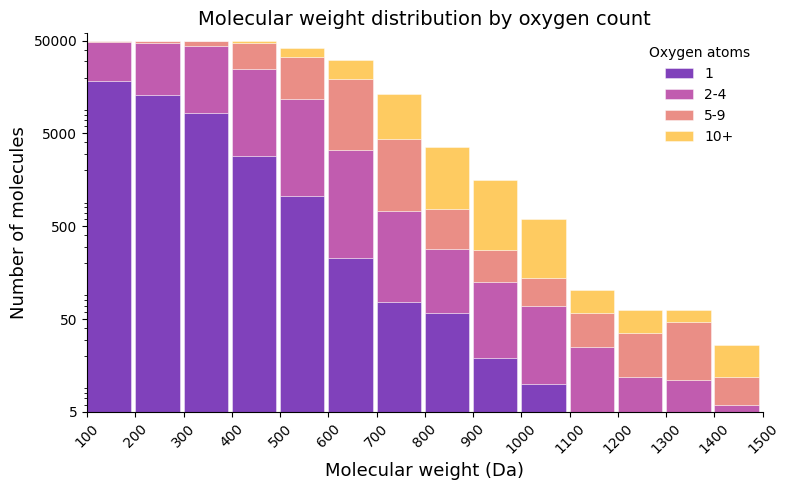

In [42]:
C_BINS   = [1, 2, 5, 10, np.inf]
C_LABELS = ['1', '2-4', '5-9', '10+']
cmap = plt.cm.get_cmap('plasma')
COLORS = [cmap(x) for x in np.linspace(0.15, 0.85, len(C_LABELS))]

df['O_group'] = pd.cut(df['n_oxygen'], bins=C_BINS, labels=C_LABELS, right=False)

# Count molecules per (MW bin, C group)
mw_bins = pd.cut(df.loc[IN_RANGE, 'mw'], bins=BINS, right=False)
stacked = (
    df.loc[IN_RANGE]
    .assign(mw_bin=mw_bins)
    .groupby(['mw_bin', 'O_group'], observed=False)
    .size()
    .unstack('O_group', fill_value=0)
)

bin_width = 100
x_pos = np.array([interval.left for interval in stacked.index])

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(stacked))
for label, color in zip(C_LABELS, COLORS):
    if label not in stacked.columns:
        continue
    vals = stacked[label].values
    ax.bar(x_pos, vals, width=bin_width * 0.92, bottom=bottom,
           label=label, color=color, align='edge', edgecolor='white', linewidth=0.4,
           alpha=0.75)
    bottom += vals

ax.set_xlabel('Molecular weight (Da)', fontsize=13)
ax.set_ylabel('Number of molecules', fontsize=13)
ax.set_title('Molecular weight distribution by oxygen count', fontsize=14)
ax.set_xticks(BINS)
ax.set_xlim(100, 1500)
ax.set_yscale('log')
ax.xaxis.set_tick_params(rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_yticks([5, 50, 500, 5000, 50000], labels=[5, 50, 500, 5000, 50000])
ax.legend(title='Oxygen atoms', frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim([5, 60000])

plt.tight_layout()
plt.savefig('mw_histogram_stacked_oxygen.png', dpi=300)
plt.show()

C:\Users\kuuli\AppData\Local\Temp\ipykernel_31652\1814197380.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('plasma')


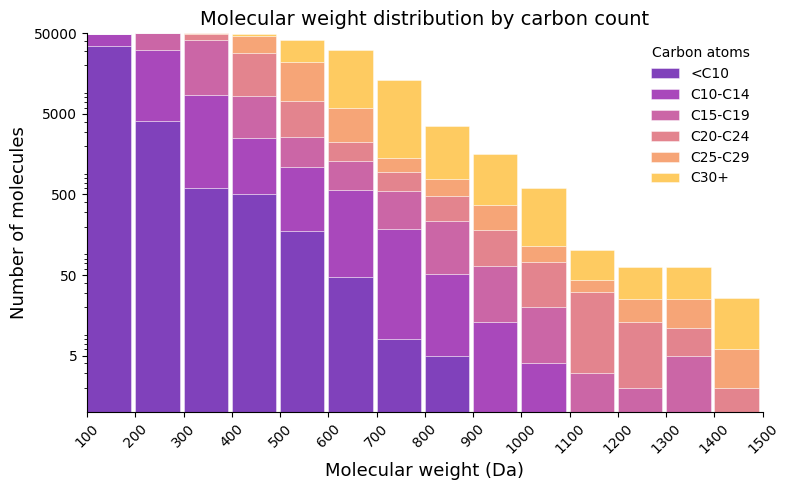

In [33]:
C_BINS   = [0, 10, 15, 20, 25, 30, np.inf]
C_LABELS = ['<C10', 'C10-C14', 'C15-C19', 'C20-C24', 'C25-C29', 'C30+']
cmap = plt.cm.get_cmap('plasma')
COLORS = [cmap(x) for x in np.linspace(0.15, 0.85, len(C_LABELS))]

df['c_group'] = pd.cut(df['n_carbon'], bins=C_BINS, labels=C_LABELS, right=False)

# Count molecules per (MW bin, C group)
mw_bins = pd.cut(df.loc[IN_RANGE, 'mw'], bins=BINS, right=False)
stacked = (
    df.loc[IN_RANGE]
    .assign(mw_bin=mw_bins)
    .groupby(['mw_bin', 'c_group'], observed=False)
    .size()
    .unstack('c_group', fill_value=0)
)

bin_width = 100
x_pos = np.array([interval.left for interval in stacked.index])

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(stacked))
for label, color in zip(C_LABELS, COLORS):
    if label not in stacked.columns:
        continue
    vals = stacked[label].values
    ax.bar(x_pos, vals, width=bin_width * 0.92, bottom=bottom,
           label=label, color=color, align='edge', edgecolor='white', linewidth=0.4,
           alpha=0.75)
    bottom += vals

ax.set_xlabel('Molecular weight (Da)', fontsize=13)
ax.set_ylabel('Number of molecules', fontsize=13)
ax.set_title('Molecular weight distribution by carbon count', fontsize=14)
ax.set_xticks(BINS)
ax.set_xlim(100, 1500)
ax.set_yscale('log')
ax.xaxis.set_tick_params(rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_yticks([5, 50, 500, 5000, 50000], labels=[5, 50, 500, 5000, 50000])
ax.legend(title='Carbon atoms', frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mw_histogram_stacked_carbon.png', dpi=300)
plt.show()

## Summary table

In [34]:
summary = df.loc[IN_RANGE].groupby('c_group', observed=False).size().rename('count')
summary = summary.to_frame()
summary['%'] = (summary['count'] / summary['count'].sum() * 100).round(1)
summary

,count,%
c_group,,
<C10,40259,13.8
C10-C14,52956,18.2
C15-C19,60985,21.0
C20-C24,34180,11.7
C25-C29,37441,12.9
C30+,65244,22.4
